In [8]:
from google.colab import files
import pandas as pd

upload = files.upload()

Saving employee_salary_regression.csv to employee_salary_regression (4).csv


In [9]:
import pandas as pd
df = pd.read_csv('employee_salary_regression.csv')
df.head(10)

,employee_id,age,years_experience,education_level,job_role,city_tier,performance_score,num_skills,remote_work,annual_salary_usd
0,EMP0001,29,9,Master,Software Engineer,1,2.4,3,0,106343.31
1,EMP0002,27,6,Bachelor,ML Engineer,3,2.1,5,1,82852.60
2,EMP0003,36,13,Master,Data Analyst,1,4.1,7,1,142019.59
3,EMP0004,43,23,High School,DevOps,1,3.1,7,1,159972.80
4,EMP0005,24,1,High School,DevOps,1,3.7,12,1,94126.86
5,EMP0006,24,3,Master,Data Analyst,1,4.6,8,1,109682.21
6,EMP0007,51,29,Bachelor,Product Manager,2,2.6,6,0,155103.12
7,EMP0008,37,16,PhD,DevOps,2,5.0,12,0,146648.13
8,EMP0009,42,22,Bachelor,Data Analyst,2,3.2,3,0,141824.61
9,EMP0010,42,21,PhD,DevOps,3,3.4,6,0,134712.86


In [10]:
df.columns

Index(['employee_id', 'age', 'years_experience', 'education_level', 'job_role',
       'city_tier', 'performance_score', 'num_skills', 'remote_work',
       'annual_salary_usd'],
      dtype='object')

In [11]:
df.select_dtypes(include="object").columns

Index(['employee_id', 'education_level', 'job_role'], dtype='object')

In [12]:
df.isnull().sum()

,0
employee_id,0
age,0
years_experience,0
education_level,0
job_role,0
city_tier,0
performance_score,0
num_skills,0
remote_work,0
annual_salary_usd,0


In [13]:
df.duplicated().sum()

np.int64(0)

In [15]:
for col in ["education_level", "job_role", "city_tier"]:
  print(df[col].value_counts())
print()

education_level
Bachelor       258
PhD            256
Master         246
High School    240
Name: count, dtype: int64
job_role
DevOps               190
Data Analyst         178
Product Manager      168
QA Engineer          165
Software Engineer    152
ML Engineer          147
Name: count, dtype: int64
city_tier
3    365
1    319
2    316
Name: count, dtype: int64



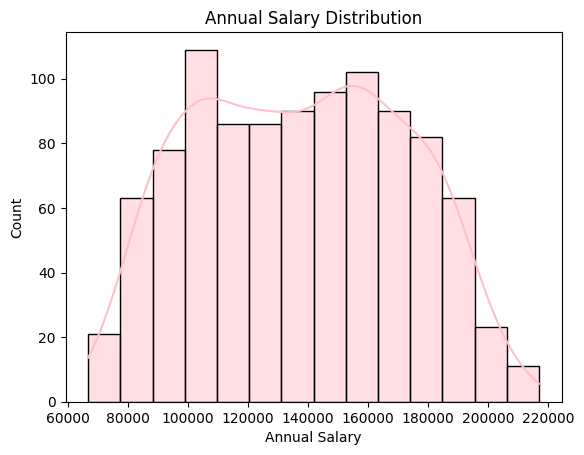

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df["annual_salary_usd"], kde=True, color="pink")
plt.title("Annual Salary Distribution")
plt.xlabel("Annual Salary")
plt.show()

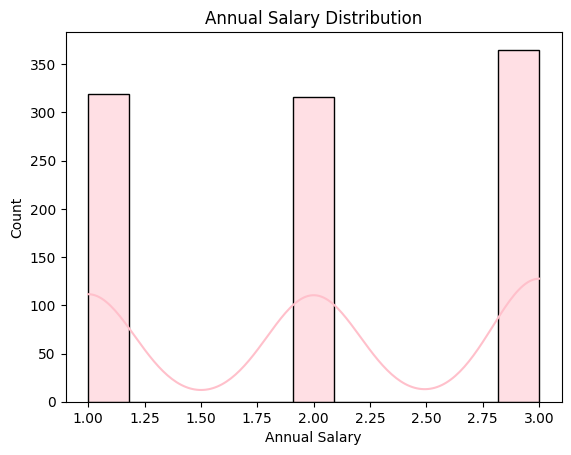

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df["city_tier"], kde=True, color="pink")
plt.title("Annual Salary Distribution")
plt.xlabel("Annual Salary")
plt.show()

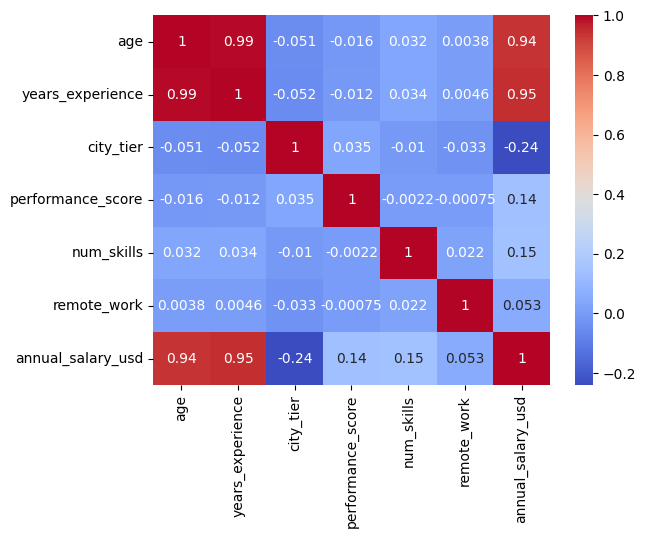

In [25]:
import seaborn as sns
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.show()

In [27]:
df_encoded = pd.get_dummies(
    df.drop(columns=["employee_id"]),
    columns=["education_level", "job_role"],
    drop_first=True
)
df_encoded.head()

,age,years_experience,city_tier,performance_score,num_skills,remote_work,annual_salary_usd,education_level_High School,education_level_Master,education_level_PhD,job_role_DevOps,job_role_ML Engineer,job_role_Product Manager,job_role_QA Engineer,job_role_Software Engineer
0,29,9,1,2.4,3,0,106343.31,False,True,False,False,False,False,False,True
1,27,6,3,2.1,5,1,82852.60,False,False,False,False,True,False,False,False
2,36,13,1,4.1,7,1,142019.59,False,True,False,False,False,False,False,False
3,43,23,1,3.1,7,1,159972.80,True,False,False,True,False,False,False,False
4,24,1,1,3.7,12,1,94126.86,True,False,False,True,False,False,False,False


In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [34]:
x = df_encoded.drop(columns=["annual_salary_usd"])
y = df_encoded["annual_salary_usd"]

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [41]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_test_pred = model.predict(X_test_scaled)

In [42]:
from sklearn.metrics import root_mean_squared_error

test_rmse = root_mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

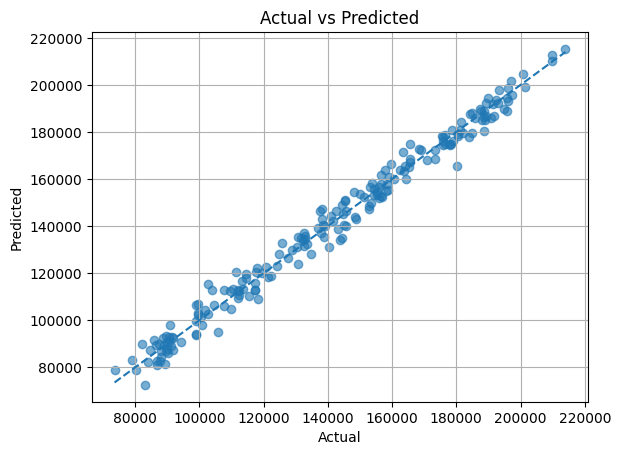

In [43]:
plt.scatter(y_test, y_test_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "--"
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.grid()
plt.show()

In [46]:
import joblib

joblib.dump(model, "salary_model.pkl")

['salary_model.pkl']